## Cell 1 — Install required packages

In [1]:

# Run once. If using a local conda/venv env, run this in a terminal instead of the notebook.
!pip install -q ollama opencv-python pillow lxml pandas numpy matplotlib tqdm


## Cell 2 — Connect to Ollama and verify Qwen3-VL is running

In [2]:

import ollama

OLLAMA_MODEL = "moondream"  # change tag to match `ollama list` output, e.g. qwen3-vl:8b

client = ollama.Client(host="http://localhost:11434")

# Verify the Ollama server is reachable and the model is pulled
try:
    models = client.list()
    names = [m.get("model", m.get("name", "")) for m in models.get("models", [])]
    print("Models available on Ollama server:")
    for n in names:
        print(" -", n)

    if not any(OLLAMA_MODEL.split(":")[0] in n for n in names):
        print(f"\n⚠️  '{OLLAMA_MODEL}' not found. Pull it first with:")
        print(f"    ollama pull {OLLAMA_MODEL}")
    else:
        print(f"\n✅ '{OLLAMA_MODEL}' is available.")
except Exception as e:
    print("❌ Could not connect to Ollama. Is it running? Try `ollama serve` in a terminal.")
    print("Error:", e)


Models available on Ollama server:
 - moondream:latest
 - qwen2.5vl:7b
 - gemma3:4b
 - llava:7b
 - qwen3-vl:latest

✅ 'moondream' is available.


## Cell 3 — Load one test image

Found 50 images.
Testing on: 00094.jpg | size: (1280, 720)


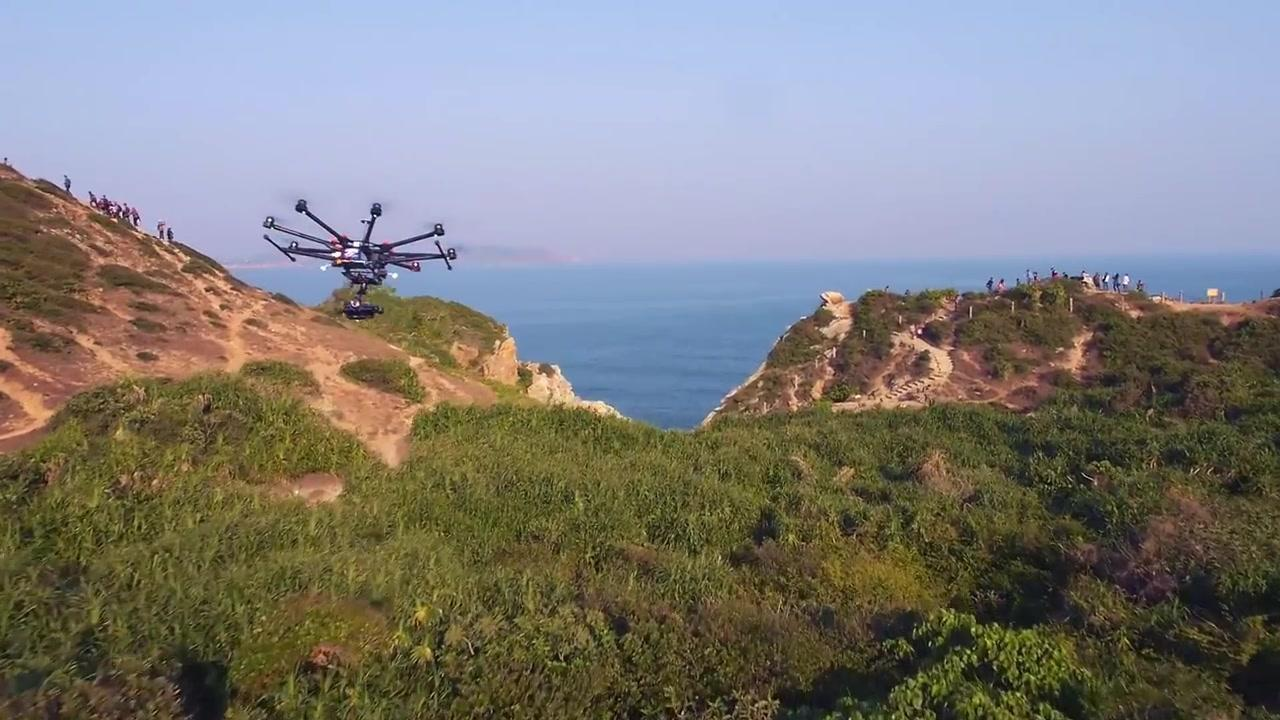

In [3]:

import os
from PIL import Image

IMAGES_DIR = r"C:\\Users\\HP\\OneDrive\\Documents\\Desktop\\vlm\\data\\detection_drone\\img"   # your images folder
ANNOTS_DIR = r"C:\\Users\\HP\\OneDrive\\Documents\\Desktop\\vlm\\data\\detection_drone\\xml"   # your ground-truth Pascal VOC XMLs
PRED_DIR   = r"C:\\Users\\HP\\OneDrive\\Documents\\Desktop\\vlm\\data\\detection_drone\\moondream_predictions_xml"
os.makedirs(PRED_DIR, exist_ok=True)

image_files = sorted([f for f in os.listdir(IMAGES_DIR)
                       if f.lower().endswith((".jpg", ".jpeg", ".png"))])
print(f"Found {len(image_files)} images.")

# Sanity check: flag any image that has no matching ground-truth XML
missing_gt = [f for f in image_files
              if not os.path.exists(os.path.join(ANNOTS_DIR, os.path.splitext(f)[0] + ".xml"))]
if missing_gt:
    print(f"WARNING: {len(missing_gt)} image(s) have NO ground-truth XML (will be treated as 'no object' GT):")
    for m in missing_gt:
        print("   -", m)

test_image_name = image_files[0]
test_image_path = os.path.join(IMAGES_DIR, test_image_name)

img = Image.open(test_image_path).convert("RGB")
print("Testing on:", test_image_name, "| size:", img.size)
img


## Cell 4 — Prompt Moondream (native detection-style prompt)

In [4]:

import base64
from io import BytesIO

def image_to_b64(pil_img):
    buf = BytesIO()
    pil_img.save(buf, format="JPEG")
    return base64.b64encode(buf.getvalue()).decode("utf-8")

# Moondream is trained on short, direct detection-style prompts (its native
# API uses model.detect(image, "object")), NOT long conversational instructions
# like general chat VLMs (Qwen/LLaVA/Gemma). Ollama's /chat endpoint doesn't
# expose Moondream's dedicated detect/point tool-call modes, so the closest
# equivalent through plain chat is a minimal, imperative-style prompt.
def build_prompt(img_w, img_h):
    return (
        "Detect: drone\\n\\n"
        f"Image size: {img_w}x{img_h} pixels, origin top-left.\\n"
        "If a drone is present, output ONLY: xmin,ymin,xmax,ymax (integer pixel "
        "coordinates of the tightest bounding box, comma-separated, no words).\\n"
        "If no drone is present, output ONLY: NO"
    )

def query_qwen_vl(pil_img, model=OLLAMA_MODEL):
    w, h = pil_img.size
    prompt = build_prompt(w, h)
    response = client.chat(
        model=model,
        messages=[{
            "role": "user",
            "content": prompt,
            "images": [image_to_b64(pil_img)],
        }],
        options={"temperature": 0.0}
    )
    return response["message"]["content"].strip()

raw_response = query_qwen_vl(img)
print("Raw model response:")
print(raw_response)


Raw model response:



## Cell 5 — Parse the response

In [5]:

import re

def parse_response(raw_text, img_w, img_h):
    # Returns (has_drone: bool, box: (xmin,ymin,xmax,ymax) or None)
    text = raw_text.strip()

    if text.upper().startswith("NO"):
        return False, None

    if "YES" not in text.upper():
        # Model didn't follow format; try to salvage any 4 numbers anyway
        nums = re.findall(r"-?\d+\.?\d*", text)
        if len(nums) >= 4:
            box = tuple(float(n) for n in nums[:4])
            return True, clamp_box(box, img_w, img_h)
        return False, None

    nums = re.findall(r"-?\d+\.?\d*", text)
    if len(nums) < 4:
        print("⚠️ Could not parse 4 coordinates from:", text)
        return True, None

    box = tuple(float(n) for n in nums[:4])
    return True, clamp_box(box, img_w, img_h)

def clamp_box(box, img_w, img_h):
    xmin, ymin, xmax, ymax = box
    xmin, xmax = sorted([xmin, xmax])
    ymin, ymax = sorted([ymin, ymax])
    xmin = max(0, min(xmin, img_w - 1))
    ymin = max(0, min(ymin, img_h - 1))
    xmax = max(0, min(xmax, img_w))
    ymax = max(0, min(ymax, img_h))
    return (int(xmin), int(ymin), int(xmax), int(ymax))

has_drone, pred_box = parse_response(raw_response, img.width, img.height)
print("Drone detected:", has_drone)
print("Predicted box:", pred_box)


Drone detected: False
Predicted box: None


## Cell 6 — Draw the predicted bounding box

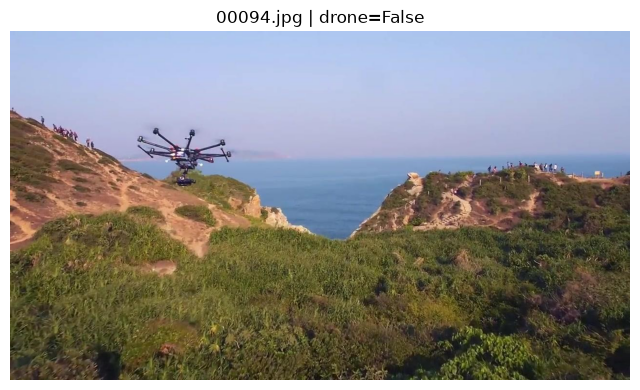

In [6]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_prediction(pil_img, box, title="Prediction"):
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(pil_img)
    if box is not None:
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                  linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
    ax.set_title(title)
    ax.axis("off")
    plt.show()

show_prediction(img, pred_box, title=f"{test_image_name} | drone={has_drone}")


## Cell 7 — Save the prediction as a Pascal VOC XML

In [7]:

from lxml import etree

def save_voc_xml(filename, img_w, img_h, box, out_dir=PRED_DIR, label="drone"):
    ann = etree.Element("annotation")
    etree.SubElement(ann, "folder").text = "images"
    etree.SubElement(ann, "filename").text = filename

    size = etree.SubElement(ann, "size")
    etree.SubElement(size, "width").text = str(img_w)
    etree.SubElement(size, "height").text = str(img_h)
    etree.SubElement(size, "depth").text = "3"

    if box is not None:
        obj = etree.SubElement(ann, "object")
        etree.SubElement(obj, "name").text = label
        etree.SubElement(obj, "difficult").text = "0"
        bnd = etree.SubElement(obj, "bndbox")
        etree.SubElement(bnd, "xmin").text = str(box[0])
        etree.SubElement(bnd, "ymin").text = str(box[1])
        etree.SubElement(bnd, "xmax").text = str(box[2])
        etree.SubElement(bnd, "ymax").text = str(box[3])

    xml_name = os.path.splitext(filename)[0] + ".xml"
    out_path = os.path.join(out_dir, xml_name)
    tree = etree.ElementTree(ann)
    tree.write(out_path, pretty_print=True, xml_declaration=True, encoding="UTF-8")
    return out_path

saved_path = save_voc_xml(test_image_name, img.width, img.height, pred_box)
print("Saved:", saved_path)


Saved: C:\\Users\\HP\\OneDrive\\Documents\\Desktop\\vlm\\data\\detection_drone\\moondream_predictions_xml\00094.xml


## Cell 8 — Run inference on all 50 images

In [8]:

from tqdm import tqdm
import time

results_log = []

for fname in tqdm(image_files, desc="Running Qwen3-VL inference"):
    fpath = os.path.join(IMAGES_DIR, fname)
    try:
        pil_img = Image.open(fpath).convert("RGB")
        raw = query_qwen_vl(pil_img)
        has_d, box = parse_response(raw, pil_img.width, pil_img.height)
        save_voc_xml(fname, pil_img.width, pil_img.height, box)
        results_log.append({
            "image": fname, "has_drone_pred": has_d,
            "box_pred": box, "raw_response": raw
        })
    except Exception as e:
        print(f"Error on {fname}: {e}")
        results_log.append({
            "image": fname, "has_drone_pred": False,
            "box_pred": None, "raw_response": f"ERROR: {e}"
        })
    time.sleep(0.1)  # small pause to avoid overloading local Ollama server

print(f"\nDone. Predictions saved to: {PRED_DIR}")


Running Qwen3-VL inference: 100%|██████████| 50/50 [01:09<00:00,  1.39s/it]


Done. Predictions saved to: C:\\Users\\HP\\OneDrive\\Documents\\Desktop\\vlm\\data\\detection_drone\\moondream_predictions_xml


## Cell 9 — Compare predicted XMLs with ground-truth XMLs

In [9]:

def parse_voc_xml(xml_path):
    # Returns (img_w, img_h, box or None) from a Pascal VOC xml file.
    tree = etree.parse(xml_path)
    root = tree.getroot()
    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)

    obj = root.find("object")
    if obj is None:
        return w, h, None

    bnd = obj.find("bndbox")
    box = (
        int(float(bnd.find("xmin").text)),
        int(float(bnd.find("ymin").text)),
        int(float(bnd.find("xmax").text)),
        int(float(bnd.find("ymax").text)),
    )
    return w, h, box

comparisons = []
for fname in image_files:
    stem = os.path.splitext(fname)[0]
    gt_path = os.path.join(ANNOTS_DIR, stem + ".xml")
    pred_path = os.path.join(PRED_DIR, stem + ".xml")

    if not os.path.exists(pred_path):
        print(f"WARNING: Missing prediction xml for {fname}")
        continue

    if os.path.exists(gt_path):
        gt_w, gt_h, gt_box = parse_voc_xml(gt_path)
    else:
        # No GT xml on disk (e.g. 00018.jpg) -> treat as "no object" ground truth
        with Image.open(os.path.join(IMAGES_DIR, fname)) as _im:
            gt_w, gt_h = _im.size
        gt_box = None

    pr_w, pr_h, pr_box = parse_voc_xml(pred_path)

    comparisons.append({
        "image": fname,
        "gt_box": gt_box,
        "pred_box": pr_box,
        "gt_has_drone": gt_box is not None,
        "pred_has_drone": pr_box is not None,
    })

print(f"Compared {len(comparisons)} image pairs.")
comparisons[:3]


Compared 50 image pairs.


[{'image': '00094.jpg',
  'gt_box': (263, 199, 459, 321),
  'pred_box': None,
  'gt_has_drone': True,
  'pred_has_drone': False},
 {'image': '00113.jpg',
  'gt_box': (614, 279, 681, 300),
  'pred_box': None,
  'gt_has_drone': True,
  'pred_has_drone': False},
 {'image': '00132.jpg',
  'gt_box': (749, 1, 943, 94),
  'pred_box': None,
  'gt_has_drone': True,
  'pred_has_drone': False}]

## Cell 10 — Compute IoU, Precision, Recall, F1-score, and mAP@0.5

In [10]:

import numpy as np

def compute_iou(boxA, boxB):
    if boxA is None or boxB is None:
        return 0.0
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - inter_area
    return inter_area / union if union > 0 else 0.0

IOU_THRESH = 0.5
tp, fp, fn, tn = 0, 0, 0, 0
ious = []

for c in comparisons:
    gt_box, pred_box = c["gt_box"], c["pred_box"]
    iou = compute_iou(gt_box, pred_box) if (gt_box and pred_box) else 0.0
    c["iou"] = iou
    ious.append(iou)

    if gt_box is not None and pred_box is not None:
        if iou >= IOU_THRESH:
            tp += 1
        else:
            fp += 1
            fn += 1  # localization miss counts as both a false positive and a missed detection
    elif gt_box is not None and pred_box is None:
        fn += 1
    elif gt_box is None and pred_box is not None:
        fp += 1
    else:
        tn += 1

precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

# mAP@0.5 for a single class ("drone"): rank by IoU as a proxy confidence score,
# then compute AP via precision-recall interpolation (11-point).
scored = sorted(comparisons, key=lambda c: c["iou"], reverse=True)
cum_tp, cum_fp = 0, 0
n_gt_positive = sum(1 for c in comparisons if c["gt_box"] is not None)
precisions, recalls = [], []

for c in scored:
    if c["gt_box"] is None:
        continue  # skip entries with no ground truth object
    if c["pred_box"] is not None and c["iou"] >= IOU_THRESH:
        cum_tp += 1
    else:
        cum_fp += 1
    p = cum_tp / (cum_tp + cum_fp)
    r = cum_tp / n_gt_positive if n_gt_positive else 0
    precisions.append(p)
    recalls.append(r)

ap = 0.0
if precisions:
    for t in np.linspace(0, 1, 11):
        p_at_r = [p for p, r in zip(precisions, recalls) if r >= t]
        ap += (max(p_at_r) if p_at_r else 0) / 11

mean_iou = float(np.mean(ious)) if ious else 0.0

print("===== Evaluation Summary =====")
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"Mean IoU (all pairs):  {mean_iou:.4f}")
print(f"Precision:             {precision:.4f}")
print(f"Recall:                {recall:.4f}")
print(f"F1-score:              {f1:.4f}")
print(f"mAP@0.5:               {ap:.4f}")


===== Evaluation Summary =====
TP=0  FP=0  FN=50  TN=0
Mean IoU (all pairs):  0.0000
Precision:             0.0000
Recall:                0.0000
F1-score:              0.0000
mAP@0.5:               0.0000


## Cell 11 — Generate a CSV and summary report

In [11]:

import pandas as pd
from datetime import datetime

df = pd.DataFrame(comparisons)
df["correct_detection"] = df["gt_has_drone"] == df["pred_has_drone"]
csv_path = "C:\\Users\\HP\\OneDrive\\Documents\\Desktop\\vlm\\data\\detection_drone\\moondream_drone_eval_results.csv"
df.to_csv(csv_path, index=False)
print("Per-image CSV saved to:", csv_path)

report_path = "C:\\Users\\HP\\OneDrive\\Documents\\Desktop\\vlm\\data\\detection_drone\\moondream_drone_eval_summary.txt"
with open(report_path, "w") as f:
    f.write("Moondream Small Drone Detection — Evaluation Report\n")
    f.write(f"Generated: {datetime.now().isoformat()}\n")
    f.write(f"Model: {OLLAMA_MODEL}\n")
    f.write(f"Images evaluated: {len(comparisons)}\n")
    f.write(f"IoU threshold: {IOU_THRESH}\n\n")
    f.write(f"TP: {tp}\nFP: {fp}\nFN: {fn}\nTN: {tn}\n\n")
    f.write(f"Mean IoU:  {mean_iou:.4f}\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall:    {recall:.4f}\n")
    f.write(f"F1-score:  {f1:.4f}\n")
    f.write(f"mAP@0.5:   {ap:.4f}\n")

print("Summary report saved to:", report_path)
df.head(10)


Per-image CSV saved to: C:\Users\HP\OneDrive\Documents\Desktop\vlm\data\detection_drone\moondream_drone_eval_results.csv
Summary report saved to: C:\Users\HP\OneDrive\Documents\Desktop\vlm\data\detection_drone\moondream_drone_eval_summary.txt


,image,gt_box,pred_box,gt_has_drone,pred_has_drone,iou,correct_detection
0,00094.jpg,"(263, 199, 459, 321)",None,True,False,0.0,False
1,00113.jpg,"(614, 279, 681, 300)",None,True,False,0.0,False
2,00132.jpg,"(749, 1, 943, 94)",None,True,False,0.0,False
3,00139.jpg,"(319, 73, 1001, 303)",None,True,False,0.0,False
4,00225.jpg,"(452, 278, 799, 375)",None,True,False,0.0,False
5,00227.jpg,"(701, 88, 1131, 319)",None,True,False,0.0,False
6,00242.jpg,"(361, 236, 481, 317)",None,True,False,0.0,False
7,00246.jpg,"(573, 258, 633, 296)",None,True,False,0.0,False
8,00253.jpg,"(483, 181, 580, 233)",None,True,False,0.0,False
9,00294.jpg,"(359, 216, 804, 361)",None,True,False,0.0,False
